In [1]:
!pip install xgboost

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [3]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [4]:
print(os.listdir('/kaggle/input/datasets'))

['paultimothymooney']


In [5]:
print(os.listdir('/kaggle/input/datasets/paultimothymooney'))

['chest-xray-pneumonia']


In [6]:
print(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia'))

['chest_xray']


In [7]:
print(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [8]:
import os

dataset_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"

print(os.listdir(dataset_path))

['val', '.DS_Store', 'test', 'train']


In [9]:
IMG_SIZE = 64

X = []
y = []

categories = ['NORMAL', 'PNEUMONIA']

train_path = os.path.join(dataset_path, 'train')

for category in categories:

    path = os.path.join(train_path, category)

    label = categories.index(category)

    for img_name in os.listdir(path):

        try:
            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img.flatten())

            y.append(label)

        except Exception as e:
            pass

In [10]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(5216, 4096)
(5216,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4172, 4096)
(1044, 4096)


In [12]:
model = XGBClassifier()

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [13]:
y_pred = model.predict(X_test)

In [14]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.9549808429118773


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       268
           1       0.97      0.97      0.97       776

    accuracy                           0.95      1044
   macro avg       0.94      0.94      0.94      1044
weighted avg       0.95      0.95      0.95      1044



In [16]:
from sklearn.decomposition import PCA

In [17]:
pca = PCA(n_components=100)

In [18]:
X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

In [19]:
print(X_train_pca.shape)
print(X_test_pca.shape)

(4172, 100)
(1044, 100)


In [20]:
model_pca = XGBClassifier()

model_pca.fit(X_train_pca, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [21]:
y_pred_pca = model_pca.predict(X_test_pca)

In [22]:
acc_pca = accuracy_score(y_test, y_pred_pca)

print("PCA + XGBoost Accuracy:", acc_pca)

PCA + XGBoost Accuracy: 0.9492337164750958


In [23]:
print(classification_report(y_test, y_pred_pca))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       268
           1       0.96      0.97      0.97       776

    accuracy                           0.95      1044
   macro avg       0.94      0.93      0.93      1044
weighted avg       0.95      0.95      0.95      1044



In [24]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.preprocessing.image import img_to_array

2026-05-17 05:59:49.735683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778997589.970991      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778997590.038838      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778997590.584357      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778997590.584387      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778997590.584390      57 computation_placer.cc:177] computation placer alr

In [25]:
vgg = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

I0000 00:00:1778997612.833477      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [26]:
def extract_features(folder_path, categories):

    features = []
    labels = []

    train_path = os.path.join(folder_path, 'train')

    for category in categories:

        path = os.path.join(train_path, category)

        label = categories.index(category)

        for img_name in os.listdir(path):

            try:
                img_path = os.path.join(path, img_name)

                img = cv2.imread(img_path)

                img = cv2.resize(img, (128, 128))

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                img = img_to_array(img)

                img = preprocess_input(img)

                img = np.expand_dims(img, axis=0)

                feature = vgg.predict(img, verbose=0)

                feature = feature.flatten()

                features.append(feature)

                labels.append(label)

            except Exception as e:
                pass

    return np.array(features), np.array(labels)

In [27]:
categories = ["NORMAL", "PNEUMONIA"]

X_vgg, y_vgg = extract_features(dataset_path, categories)

I0000 00:00:1778997617.265988     139 service.cc:152] XLA service 0x7cb0dc0034c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778997617.266025     139 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778997617.434387     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778997619.004392     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [28]:
print(X_vgg.shape)
print(y_vgg.shape)

(5216, 8192)
(5216,)


In [29]:
X_train_vgg, X_test_vgg, y_train_vgg, y_test_vgg = train_test_split(
    X_vgg,
    y_vgg,
    test_size=0.2,
    random_state=42,
    stratify=y_vgg
)

In [30]:
model_vgg = XGBClassifier()

model_vgg.fit(X_train_vgg, y_train_vgg)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
y_pred_vgg = model_vgg.predict(X_test_vgg)

In [32]:
acc_vgg = accuracy_score(y_test_vgg, y_pred_vgg)

print("VGG16 + XGBoost Accuracy:", acc_vgg)

VGG16 + XGBoost Accuracy: 0.9703065134099617


In [33]:
print(classification_report(y_test_vgg, y_pred_vgg))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       268
           1       0.98      0.98      0.98       776

    accuracy                           0.97      1044
   macro avg       0.96      0.96      0.96      1044
weighted avg       0.97      0.97      0.97      1044



In [34]:
from sklearn.model_selection import train_test_split

In [35]:
percentages = [0.2, 0.4, 0.6, 0.8, 1.0]

In [36]:
raw_acc = []
pca_acc = []
vgg_acc = []

In [37]:
for p in percentages:

    print(f"\nTraining with {int(p*100)}% data")

    # ---------------- RAW XGBOOST ----------------

    if p < 1.0:

        X_sub, _, y_sub, _ = train_test_split(
            X_train,
            y_train,
            train_size=p,
            random_state=42,
            stratify=y_train
        )

    else:

        X_sub = X_train
        y_sub = y_train

    model_raw = XGBClassifier()

    model_raw.fit(X_sub, y_sub)

    y_pred_raw = model_raw.predict(X_test)

    acc_raw = accuracy_score(y_test, y_pred_raw)

    raw_acc.append(acc_raw)

    print("Raw XGB:", acc_raw)

    # ---------------- PCA + XGBOOST ----------------

    if p < 1.0:

        X_sub_pca, _, y_sub_pca, _ = train_test_split(
            X_train_pca,
            y_train,
            train_size=p,
            random_state=42,
            stratify=y_train
        )

    else:

        X_sub_pca = X_train_pca
        y_sub_pca = y_train

    model_pca = XGBClassifier()

    model_pca.fit(X_sub_pca, y_sub_pca)

    y_pred_pca = model_pca.predict(X_test_pca)

    acc_pca = accuracy_score(y_test, y_pred_pca)

    pca_acc.append(acc_pca)

    print("PCA + XGB:", acc_pca)

    # ---------------- VGG16 + XGBOOST ----------------

    if p < 1.0:

        X_sub_vgg, _, y_sub_vgg, _ = train_test_split(
            X_train_vgg,
            y_train_vgg,
            train_size=p,
            random_state=42,
            stratify=y_train_vgg
        )

    else:

        X_sub_vgg = X_train_vgg
        y_sub_vgg = y_train_vgg

    model_vgg = XGBClassifier()

    model_vgg.fit(X_sub_vgg, y_sub_vgg)

    y_pred_vgg = model_vgg.predict(X_test_vgg)

    acc_vgg = accuracy_score(y_test_vgg, y_pred_vgg)

    vgg_acc.append(acc_vgg)

    print("VGG16 + XGB:", acc_vgg)


Training with 20% data
Raw XGB: 0.9243295019157088
PCA + XGB: 0.9176245210727969
VGG16 + XGB: 0.9549808429118773

Training with 40% data
Raw XGB: 0.9501915708812261
PCA + XGB: 0.9367816091954023
VGG16 + XGB: 0.9588122605363985

Training with 60% data
Raw XGB: 0.9549808429118773
PCA + XGB: 0.9377394636015326
VGG16 + XGB: 0.960727969348659

Training with 80% data
Raw XGB: 0.9492337164750958
PCA + XGB: 0.9444444444444444
VGG16 + XGB: 0.9674329501915708

Training with 100% data
Raw XGB: 0.9549808429118773
PCA + XGB: 0.9492337164750958
VGG16 + XGB: 0.9703065134099617


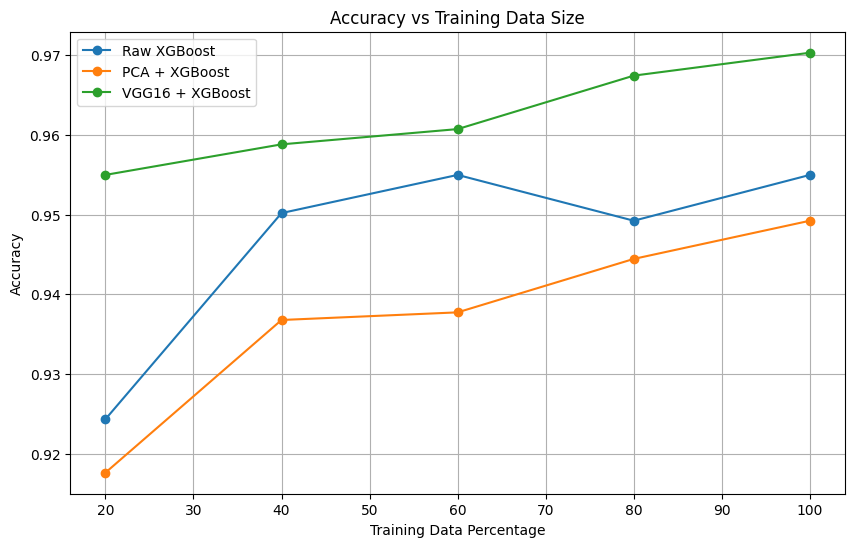

In [38]:
import matplotlib.pyplot as plt

percent_labels = [20, 40, 60, 80, 100]

plt.figure(figsize=(10,6))

plt.plot(percent_labels, raw_acc, marker='o', label='Raw XGBoost')

plt.plot(percent_labels, pca_acc, marker='o', label='PCA + XGBoost')

plt.plot(percent_labels, vgg_acc, marker='o', label='VGG16 + XGBoost')

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Training Data Size")

plt.legend()

plt.grid(True)

plt.show()

In [39]:

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    sensitivity_list = []
    specificity_list = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        sensitivity = TP / (TP + FN + 1e-10)
        specificity = TN / (TN + FP + 1e-10)

        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)

    sensitivity = np.mean(sensitivity_list)
    specificity = np.mean(specificity_list)

    print("Accuracy    :", round(accuracy, 4))
    print("F1 Score    :", round(f1, 4))
    print("Sensitivity :", round(sensitivity, 4))
    print("Specificity :", round(specificity, 4))

    return accuracy, f1, sensitivity, specificity


In [40]:
compute_metrics(y_test, y_pred)

Accuracy    : 0.955
F1 Score    : 0.9548
Sensitivity : 0.938
Specificity : 0.938


(0.9549808429118773,
 0.9548411734065259,
 np.float64(0.9379616094781501),
 np.float64(0.9379616094781501))

In [41]:
compute_metrics(y_test, y_pred_pca)

Accuracy    : 0.9492
F1 Score    : 0.9489
Sensitivity : 0.9268
Specificity : 0.9268


(0.9492337164750958,
 0.9488805193722792,
 np.float64(0.926767579627408),
 np.float64(0.926767579627408))

In [42]:
compute_metrics(y_test_vgg, y_pred_vgg)

Accuracy    : 0.9703
F1 Score    : 0.9704
Sensitivity : 0.9641
Specificity : 0.9641


(0.9703065134099617,
 0.9703957435564069,
 np.float64(0.9641483305121461),
 np.float64(0.9641483305121461))